<a href="https://colab.research.google.com/github/HarshiniAiyyer/Relearning/blob/main/pytorch/5_Custom_Dataset_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#5. Custom Dataset

- Multiclass classification model to classify pizza, sushi and steak images

### Import libraries and applying device-agnostic code

In [1]:
import torch
from torch import nn

#setup device agnostic code right from the start

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Get data

- food101 datasets (from Pytorch website)
- subset of food101, 101 food categories originally, but here only 3 for now.

In [2]:
from os import path
import requests
import zipfile
from pathlib import Path

#setup path to a data folder
datapath = Path("data/")
imagepath = datapath / "pizza_steak_sushi"

#if image folder doesnt exist, download and prepare it
if imagepath.is_dir():
  print(f"{imagepath} directory already exizsts")
else:
  print(f"{imagepath} doesnt exist. creating one.")
  imagepath.mkdir(parents=True, exist_ok=True)

data/pizza_steak_sushi directory already exizsts


#### Downloading the images

In [3]:
with open(datapath / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")

  print('downloading..')
  f.write(request.content)

#unzip

with zipfile.ZipFile(datapath / "pizza_steak_sushi.zip") as zip_ref:
  print("unzipping pizza, steak and sushi data..")
  zip_ref.extractall(imagepath)

downloading..
unzipping pizza, steak and sushi data..


### Data Preparation and Exploration

- Convert the images to tensors

In [4]:
import os

def wkthru(dir_path):
  ### returns the contents of the directory
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"there are {len(dirnames)} directories and {len(filenames)} image")

In [5]:
wkthru(imagepath)

there are 2 directories and 0 image
there are 3 directories and 0 image
there are 0 directories and 78 image
there are 0 directories and 75 image
there are 0 directories and 72 image
there are 3 directories and 0 image
there are 0 directories and 25 image
there are 0 directories and 19 image
there are 0 directories and 31 image


#### Setup train and testing paths

In [6]:
# Setup train and testing paths
train_dir = imagepath / "train"
test_dir = imagepath / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

#### Visualizing images with PIL package

- get all image paths
- pick a random image path using Python's random_choice()
- get the image class names using ```pathlib.Path.parent.stem```
- since we are working with images, lets use PIL package

- show the image and print metadata

random image path: data/pizza_steak_sushi/train/steak/3577618.jpg
Image class: steak
Image height: 512
image width: 512


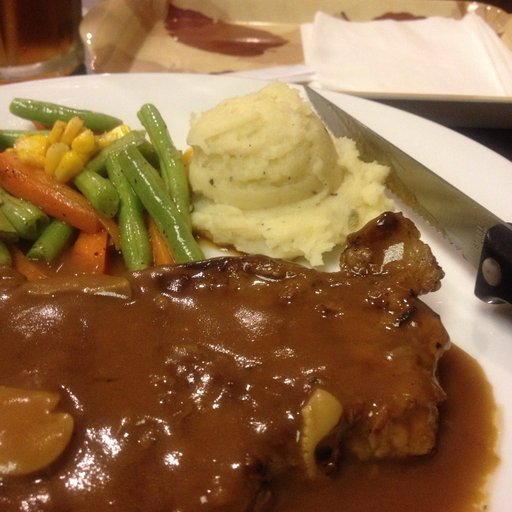

In [7]:
import random
from PIL import Image

#set seed
#random.seed(42)

#1. Get all image paths
image_path_list = list(imagepath.glob("*/*/*.jpg"))

#2, random img path
randimagepath = random.choice(image_path_list)

#3. get image class from path name (image class)
imageclass = randimagepath.parent.stem

#4. open image
img = Image.open(randimagepath)

#5. print metadata
print(f"random image path: {randimagepath}")
print(f"Image class: {imageclass}")
print(f"Image height: {img.height}")
print(f"image width: {img.width}")

#display the random image
img

#### Visualizing with matplotlib package

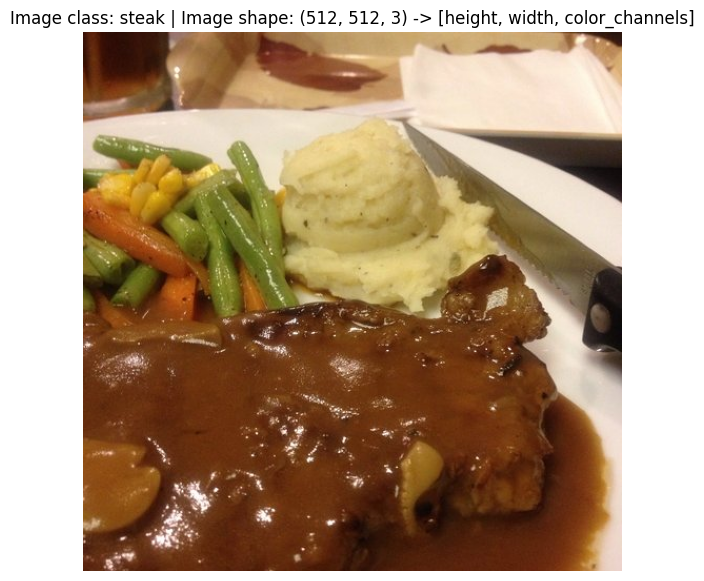

In [8]:
import numpy as np
import matplotlib.pyplot as plt

#turn the image into an array
imgasarray = np.asarray(img)

#plot image
plt.figure(figsize=(10,7))
plt.imshow(imgasarray)
plt.title(f"Image class: {imageclass} | Image shape: {imgasarray.shape} -> [height, width, color_channels]")
plt.axis(False);

### Data transforming

- turn to target data into tensors
- turn into a ```torch.utils.data.Dataset``` and then a ```torch.utils.data.Dataloader```

In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#### Transform data with ```torchvision.transforms```

In [10]:
#writing an image transform

data_transform = transforms.Compose([

    #resizing
    transforms.Resize(size=(64,64)),

    #flip the image
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance

    # Turn the image into a torch.Tensor
    transforms.ToTensor() # converts all pixel values from 0 to 255 to be between 0.0 and 1.0
])

In [11]:
data_transform(img).shape

torch.Size([3, 64, 64])

Note: we might have to use .permute() for matplotlib because

- order of dimensions need to be changed to perform transforms

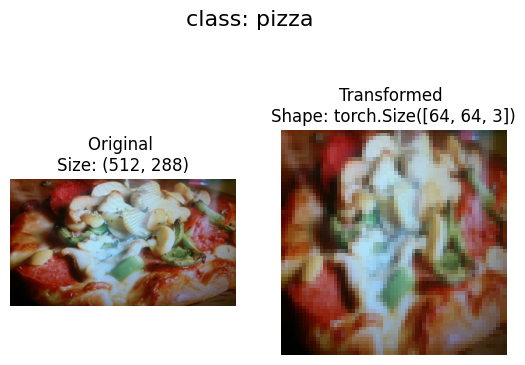

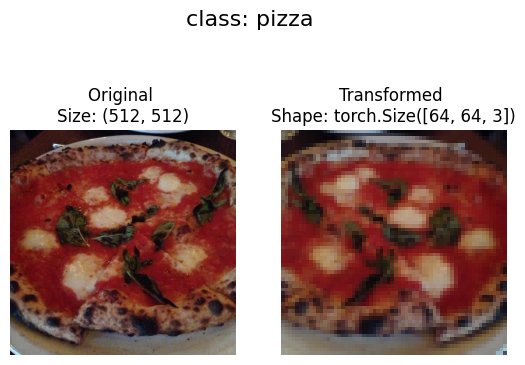

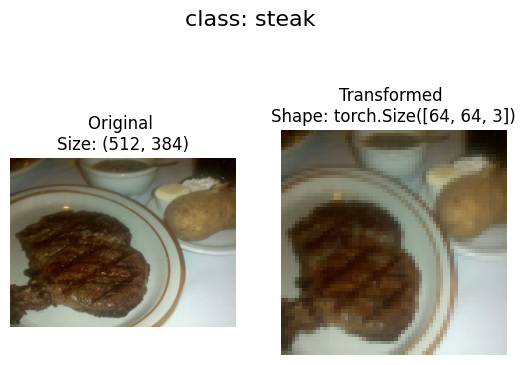

In [12]:
def plot_transforms(image_paths, transform, n = 3, seed = 42):
  if seed:
    random.seed(seed)

  random_image_paths = random.sample(image_paths, k = n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            #transform and plot img
            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nShape: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"class: {image_path.parent.stem}", fontsize = 16)

plot_transforms(image_path_list,
                        transform=data_transform,
                        n=3)


### Data loading



### Option 1: Using ```ImageFolder```

In [13]:
from torchvision import datasets


train_data = datasets.ImageFolder(root = train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root = test_dir,
                                  transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [14]:
classnames = train_data.classes

class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

##### Visualizing an image sample

In [15]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


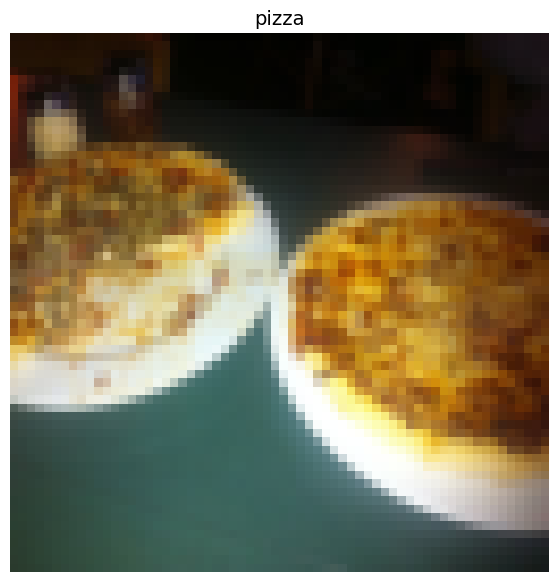

In [16]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(classnames[label], fontsize=14);

##### Turn loaded images into ```DataLoader```

In [17]:
# Turn train and test Datasets into DataLoaders
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=1, # how many samples per batch?
                              num_workers=1, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True) # shuffle the data?

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=1,
                             num_workers=1,
                             shuffle=False) # don't usually need to shuffle testing data

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7abf7730ce60>,
 <torch.utils.data.dataloader.DataLoader at 0x7abf772f3b00>)

In [18]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


### Option 2: with a custom ```Dataset``` option

1. to load images from the file
2. to get classnames from dataset
3. get classes as dictionary from dataset

pros:
1. can create a dataset from scratch
2. not limiting to the pytroch prebuilt dataset functions

cons:
1. even though from scratch is possible, doesnt mean it wud work
2. dataset customizing results in writing more code, which cud be prone to errors or performance issues

In [19]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [20]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

#### create helper function to get class names

Steps to follow:

- get class names with ```os.scandir()``` to traverse a target directory (since the dir is in standard img classfn format)

- Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).

- Turn the class names into a dictionary of numerical labels, one for each class.

In [21]:
# Setup path for target directory
target_directory = train_dir
print(f"Target directory: {target_directory}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(imagepath / "train"))])
print(f"Class names found: {class_names_found}")

Target directory: data/pizza_steak_sushi/train
Class names found: ['pizza', 'steak', 'sushi']


In [22]:
# Make function to find classes in target directory
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in a target directory."""

    # 1. Get the class names by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # 2. Raise an error if class names not found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

    # 3. Create a dictionary of index labels (computers prefer numerical rather than string labels)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [23]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

#### Create a custom ```Dataset``` to replicate ImageFolder

1. Subclass torch.utils.data.Dataset.
2. Init our subclass with a targ_dir parameter (the target data directory) and transform parameter (so we have the option to transform our data if needed).

3. Create several attributes for,

- paths (the paths of our target images),
- transform (the transforms we might like to use, this can be None),
- classes: a list of the target classes
- class_to_idx: a dict of the target classes mapped to integer labels

4. Create a function to load images from file and return them, this could be using PIL or torchvision.io (for input/output of vision data).

5. Overwrite the __len__ method of torch.utils.data.Dataset to return the number of samples in the Dataset, this is recommended but not required. This is so you can call len(Dataset).

6. Overwrite the __getitem__ method of torch.utils.data.Dataset to return a single sample from the Dataset, this is required.

In [24]:
# Write a custom dataset class (inherits from torch.utils.data.Dataset)
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):

    # 2. Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, targ_dir: str, transform=None):

        # 3. Create class attributes
        # Get all image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))

        # note: you'd have to update this if you've got .png's or .jpeg's
        # Setup transforms
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(targ_dir)

    # 4. Make function to load images
    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a path and returns it."
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
    def __len__(self) -> int:
        "Returns the total number of samples."
        return len(self.paths)

    # 6. Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X, y)."
        img = self.load_image(index)
        class_name  = self.paths[index].parent.name # expects path in data_folder/class_name/image.jpeg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx
            # return data, label (X, y)
        else:
            return img, class_idx # return data, label (X, y)

#### Create a transform

In [25]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize(size = (64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()

])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

#### Test it out

In [26]:
traincustom = ImageFolderCustom(targ_dir=train_dir,
                                transform = train_transforms)

testcustom = ImageFolderCustom(targ_dir=test_dir,
                                transform = test_transforms)

In [27]:
traincustom, testcustom

(<__main__.ImageFolderCustom at 0x7abf771f4530>,
 <__main__.ImageFolderCustom at 0x7abf772efc80>)

#### Check for equality between original imagefolder and the custom function we just wrote

In [28]:
print(traincustom.classes == train_data.classes)
print(testcustom.classes == test_data.classes)

True
True


#### Create function to display random images

1. take in any dataset and no of other parameters such as classnames and img

2. cap the no of images to 10

3. set random seed

4. get list of random sample indexes from the target dataset

5. setup a matplotlib plot

6. loop thru sample images and plot

7. make sure img dimensions line up with matplotlib

In [29]:
#1.

def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

  #2. adjust display if n is too high

  if n > 10:
    n = 10
    display_shape = False
    print(f"capping n to 10")

  #3. set the seed
  if seed:
    random.seed(seed)

  #4. get random sample indexes
  random_samples_idx = random.sample(range(len(dataset)), k = n)

  #5. setup plot
  plt.figure(figsize = (16,8))

  #6. loop thru random indexes
  for i, targsample in enumerate(random_samples_idx):
    targ_img, targ_label = dataset[targsample][0], dataset[targsample][1]

    #7. adjust tensor dimensions for plotting
    targ_image_adjust = targ_img.permute(1,2,0)

    #plot adjusted samples

    plt.subplot(1,n,i+1)
    plt.imshow(targ_image_adjust)
    plt.axis("off")
    if classes:
      title = f"classes: {classes[targ_label]}"
    if display_shape:
      title = title + f"\nshape: {targ_image_adjust.shape}"
    plt.title(title)


##### Display images from traindata

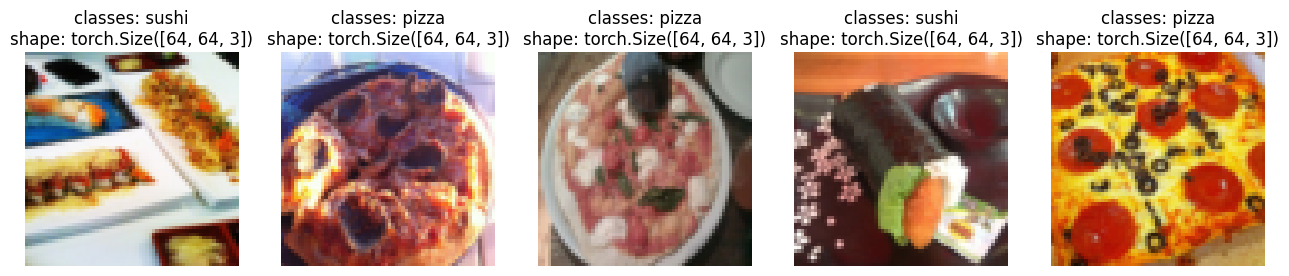

In [30]:
display_random_images(train_data,
                      n=5,
                      classes=classnames,
                      seed=42)

##### Display random images from the ImageFolderCustom dataset

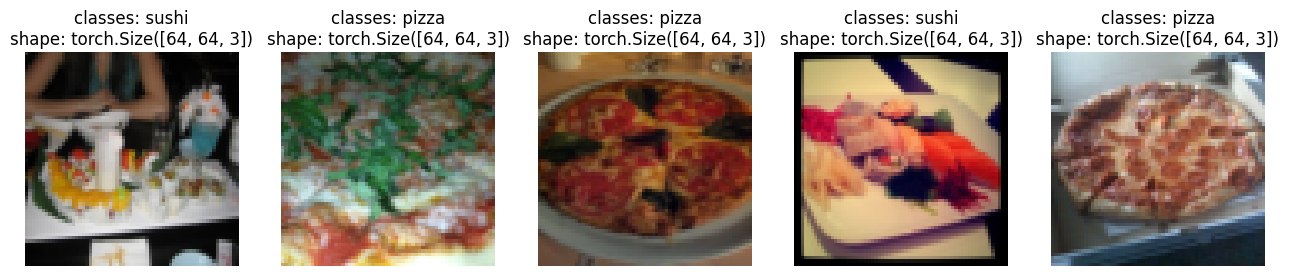

In [31]:
display_random_images(traincustom,
                      n=5,
                      classes=classnames,
                      seed=42)

#### Turn custom loaded images into Dataloader

In [32]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

traincustom_dataloader = DataLoader(
    dataset = traincustom, batch_size = BATCH_SIZE,
    num_workers = NUM_WORKERS, shuffle = True)

testcustom_dataloader = DataLoader(
    dataset = testcustom, batch_size = BATCH_SIZE,
    num_workers = NUM_WORKERS)


traincustom_dataloader, testcustom_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7abf772ec740>,
 <torch.utils.data.dataloader.DataLoader at 0x7abf7738ecf0>)

In [33]:
# Get image and label from custom DataLoader
img_custom, label_custom = next(iter(traincustom_dataloader))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}")

Image shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


### Data Augmentation

- artificially increasing the diversity of the images so that the data can be learnt in many ways

In [34]:
from torchvision import transforms

traintransform = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

testtransform = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.ToTensor()
])

##### Display

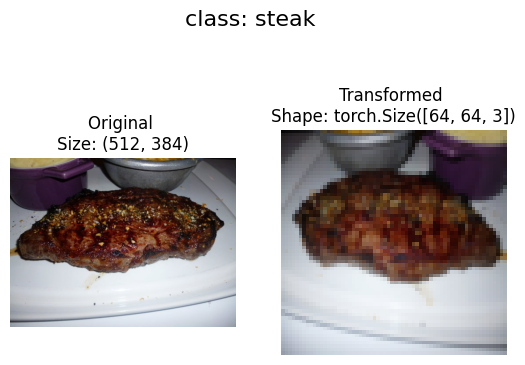

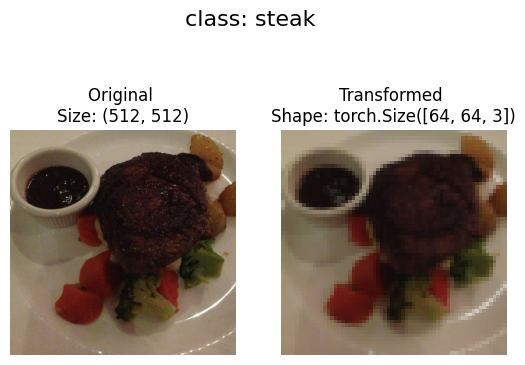

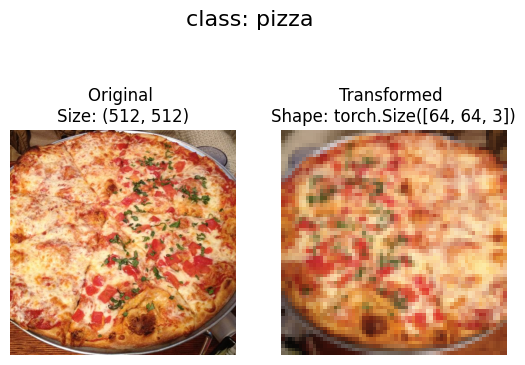

In [35]:
# Get all image paths
image_path_list = list(imagepath.glob("*/*/*.jpg"))

# Plot random images
plot_transforms(
    image_paths=image_path_list,
    transform=train_transforms,
    n=3,
    seed=None
)

### Model 0: TinyVGG without data augmentation

In [36]:
# Create simple transform
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

In [37]:
#1. LOAD AND TRANSFORM DATA
from torchvision import datasets

trainsimple = datasets.ImageFolder(
    root = train_dir, transform = simple_transform
)

testsimple = datasets.ImageFolder(
    root = test_dir, transform = simple_transform
)

#2. TURN THE DATASETS INTO DATALOADERS
import os
from torch.utils.data import DataLoader

#setup
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

#CREATE DATALOADER

trainsimple_dataloader = DataLoader(
    dataset = trainsimple, batch_size = BATCH_SIZE,
    num_workers = NUM_WORKERS, shuffle = True
)

testsimple_dataloader = DataLoader(
    dataset = testsimple, batch_size = BATCH_SIZE,
    num_workers = NUM_WORKERS
)


#### Create TinyVGG model class

In [38]:
class TinyVGG(nn.Module):
  """
  Model architecture copying TinyCGG from CNN explainer

  """

  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3, stride = 1, padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units, # Corrected in_channels
                  out_channels = hidden_units,
                  kernel_size = 3, stride = 1, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )

    self.conv_block_2 = nn.Sequential( # Added conv_block_2
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3, stride = 1, padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3, stride = 1, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        # After two MaxPool2d layers (kernel_size=2, stride=2) on a 64x64 image,
        # the spatial dimensions become (64/2/2) x (64/2/2) = 16x16.
        # So, in_features = hidden_units * 16 * 16
        nn.Linear(in_features = hidden_units * 16 * 16,
                  out_features=output_shape)
    )

  def forward(self, x: torch.Tensor): # Corrected indentation for forward method
    x = self.conv_block_1(x)
    # print(x.shape) # Uncomment for debugging
    x = self.conv_block_2(x)
    # print(x.shape) # Uncomment for debugging
    x = self.classifier(x)
    # print(x.shape) # Uncomment for debugging

    return x


In [39]:
torch.manual_seed(42)

model0 = TinyVGG(input_shape=3,
                 # number of color channels (3 for RGB)
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

model0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

#### Try a forward pass on a single image (to test the model)

In [40]:
#get a single image batch

imgbatch, labelbatch = next(iter(trainsimple_dataloader))
imgbatch, labelbatch

(tensor([[[[0.9882, 0.9882, 0.9882,  ..., 0.2314, 0.2627, 0.2902],
           [0.9882, 0.9882, 0.9922,  ..., 0.2275, 0.2980, 0.2471],
           [0.9882, 0.9882, 0.9922,  ..., 0.2235, 0.3098, 0.2471],
           ...,
           [0.1137, 0.1176, 0.1176,  ..., 0.1765, 0.1843, 0.1804],
           [0.1294, 0.1412, 0.1255,  ..., 0.1412, 0.1294, 0.1373],
           [0.1451, 0.1490, 0.1255,  ..., 0.1255, 0.1255, 0.1216]],
 
          [[0.9490, 0.9569, 0.9529,  ..., 0.1529, 0.1686, 0.1961],
           [0.9451, 0.9608, 0.9804,  ..., 0.1529, 0.2078, 0.1882],
           [0.9333, 0.9569, 0.9882,  ..., 0.1725, 0.2431, 0.1686],
           ...,
           [0.0431, 0.0392, 0.0392,  ..., 0.1412, 0.1451, 0.1294],
           [0.0431, 0.0471, 0.0431,  ..., 0.1020, 0.0980, 0.1020],
           [0.0510, 0.0510, 0.0431,  ..., 0.0627, 0.0706, 0.0745]],
 
          [[0.8039, 0.7882, 0.7843,  ..., 0.2078, 0.2353, 0.2510],
           [0.7922, 0.8431, 0.8706,  ..., 0.1765, 0.2196, 0.2157],
           [0.7765, 0.84

In [41]:
#forward pass
imgbatch = imgbatch.to(device)
model0(imgbatch)

tensor([[0.0578, 0.0634, 0.0351],
        [0.0657, 0.0650, 0.0398],
        [0.0702, 0.0678, 0.0412],
        [0.0687, 0.0646, 0.0417],
        [0.0625, 0.0613, 0.0355],
        [0.0587, 0.0595, 0.0358],
        [0.0634, 0.0637, 0.0376],
        [0.0653, 0.0615, 0.0376],
        [0.0678, 0.0621, 0.0349],
        [0.0620, 0.0599, 0.0371],
        [0.0607, 0.0628, 0.0387],
        [0.0638, 0.0589, 0.0352],
        [0.0658, 0.0611, 0.0369],
        [0.0703, 0.0689, 0.0330],
        [0.0557, 0.0571, 0.0356],
        [0.0632, 0.0642, 0.0388],
        [0.0639, 0.0616, 0.0375],
        [0.0605, 0.0600, 0.0374],
        [0.0623, 0.0627, 0.0368],
        [0.0740, 0.0676, 0.0400],
        [0.0621, 0.0613, 0.0361],
        [0.0632, 0.0599, 0.0366],
        [0.0662, 0.0627, 0.0334],
        [0.0637, 0.0622, 0.0394],
        [0.0670, 0.0666, 0.0363],
        [0.0650, 0.0601, 0.0405],
        [0.0639, 0.0597, 0.0395],
        [0.0733, 0.0687, 0.0412],
        [0.0697, 0.0631, 0.0402],
        [0.062

##### Torchinfo for summary of the model

In [42]:
!pip install -q torchinfo

In [43]:
from torchinfo import summary
summary(model0, input_size = [1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

#### Create training and testing loop functions

- ```train_step()``` : takes in a model and dataloader and trains the model on the dataloader

- ```test_step()``` : takes in a model and dataloader and evaluates the model on the dataloader

- ```train()``` - performs 1. and 2. together for a given number of epochs and returns a results dictionary.

In [44]:
#training step function


def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device = device):

  #put the model in train mode
  model.train()

  #setup train loss and train acc values - we do this batch wise
  train_loss, train_acc = 0, 0

  #loop thru dataloader data batches

  for batch, (x,y) in enumerate(dataloader):

    #send data to the target device
    x , y = x.to(device), y.to(device)

    #1. Forward pass
    y_pred = model(x)

    #2. loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    #3. optimizer zero grad
    optimizer.zero_grad()

    #4. loss backward
    loss.backward()

    #5. optimzier
    optimizer.step()

    #calculate accuracy metric
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  #adjust metrics to get average loss and accuracy per batch

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [45]:
#testing step function

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device = device):

  #put model in eval mode
  model.eval()

  #setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for batch, (x,y) in enumerate(dataloader):
      x, y = x.to(device), y.to(device)

      #1. forward pass
      test_pred_logits = model(x)

      #2. calcualte and accumulate loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      #calculate and accummulate accuracy

      test_pred_labels = test_pred_logits.argmax(dim = 1)
      test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

  #adjust metrics to get average loss and accuracy per batch

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

#### Create a train() function to combine train_step() and test_step()

In [46]:
from tqdm.auto import tqdm

#1. create a train function that takes in various model parameters + optimizer

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device = device):

  #2. create an empty results dictionary

  results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

  #3. Loop thru training and testing steps for a number of epochs

  for epoch in tqdm(range(epochs)):

    train_loss, train_acc = train_step(
        model = model, dataloader = train_dataloader,
        loss_fn = loss_fn, optimizer = optimizer, device = device)
    test_loss, test_acc = test_step(
        model = model, dataloader = test_dataloader,
        loss_fn = loss_fn, device = device)

  #4. Print out what is happening

    print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

  #5. Update results dictionary
    results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
    results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
    results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
    results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

  #6. returns the filled results at the end of the epoch

  return results

#### Train and evaluate model 0

In [47]:
#set random seeds

torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set number of epochs

NUM_EPOCHS = 5

#recreate instance of tinyvgg

model0 = TinyVGG(input_shape=3,
                 hidden_units=10,
                 output_shape=len(train_data.classes)).to(device)

# setup loss function and optimizer

loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(params = model0.parameters(),
                       lr = 0.001)

#start the timer
from timeit import default_timer as timer
start_time = timer()

#train model0
model0_results = train(model=model0,
                        train_dataloader=trainsimple_dataloader,
                        test_dataloader=testsimple_dataloader,
                        optimizer=opt,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1078 | train_acc: 0.2578 | test_loss: 1.1362 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0846 | train_acc: 0.4258 | test_loss: 1.1622 | test_acc: 0.1979
Epoch: 3 | train_loss: 1.1153 | train_acc: 0.2930 | test_loss: 1.1695 | test_acc: 0.1979
Epoch: 4 | train_loss: 1.0990 | train_acc: 0.2891 | test_loss: 1.1342 | test_acc: 0.1979
Epoch: 5 | train_loss: 1.0989 | train_acc: 0.2930 | test_loss: 1.1434 | test_acc: 0.1979
Total training time: 6.931 seconds


In [48]:
model0_results

{'train_loss': [1.1078356504440308,
  1.0846450924873352,
  1.1152650266885757,
  1.0990201532840729,
  1.0989302843809128],
 'train_acc': [0.2578125, 0.42578125, 0.29296875, 0.2890625, 0.29296875],
 'test_loss': [1.1362075805664062,
  1.1621689796447754,
  1.1694740851720173,
  1.1342329581578572,
  1.1434262990951538],
 'test_acc': [0.2604166666666667,
  0.19791666666666666,
  0.19791666666666666,
  0.19791666666666666,
  0.19791666666666666]}

#### Plotting loss curves for the model

- Loss curves show the model's results over time.

- How your model performs on different datasets (e.g. training and test).

In [49]:
model0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [50]:
def plotloss(results: Dict[str, List[float]]):
  """Plots training curves of a results dictionary"""

  #get loss values of the results dictionary

   # Get the loss values of the results dictionary (training and test)
  loss = results['train_loss']
  test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
  accuracy = results['train_acc']
  test_accuracy = results['test_acc']

  # Figure out how many epochs there were
  epochs = range(len(results['train_loss']))

  # Setup a plot
  plt.figure(figsize=(15, 7))

  # Plot loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label='train_loss')
  plt.plot(epochs, test_loss, label='test_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label='train_accuracy')
  plt.plot(epochs, test_accuracy, label='test_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

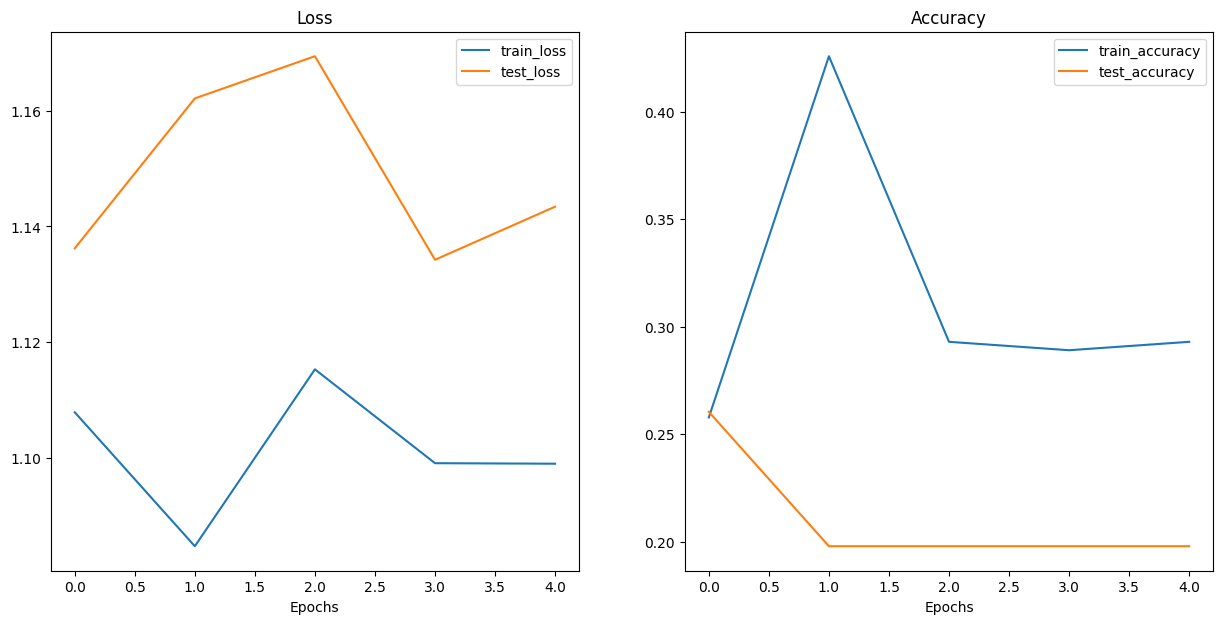

In [51]:
plotloss(model0_results)

#### Underfitting and overfitting

- overfitting is when ur model learns the data too well.

- one way reduce overfitting is to perform data augmentation

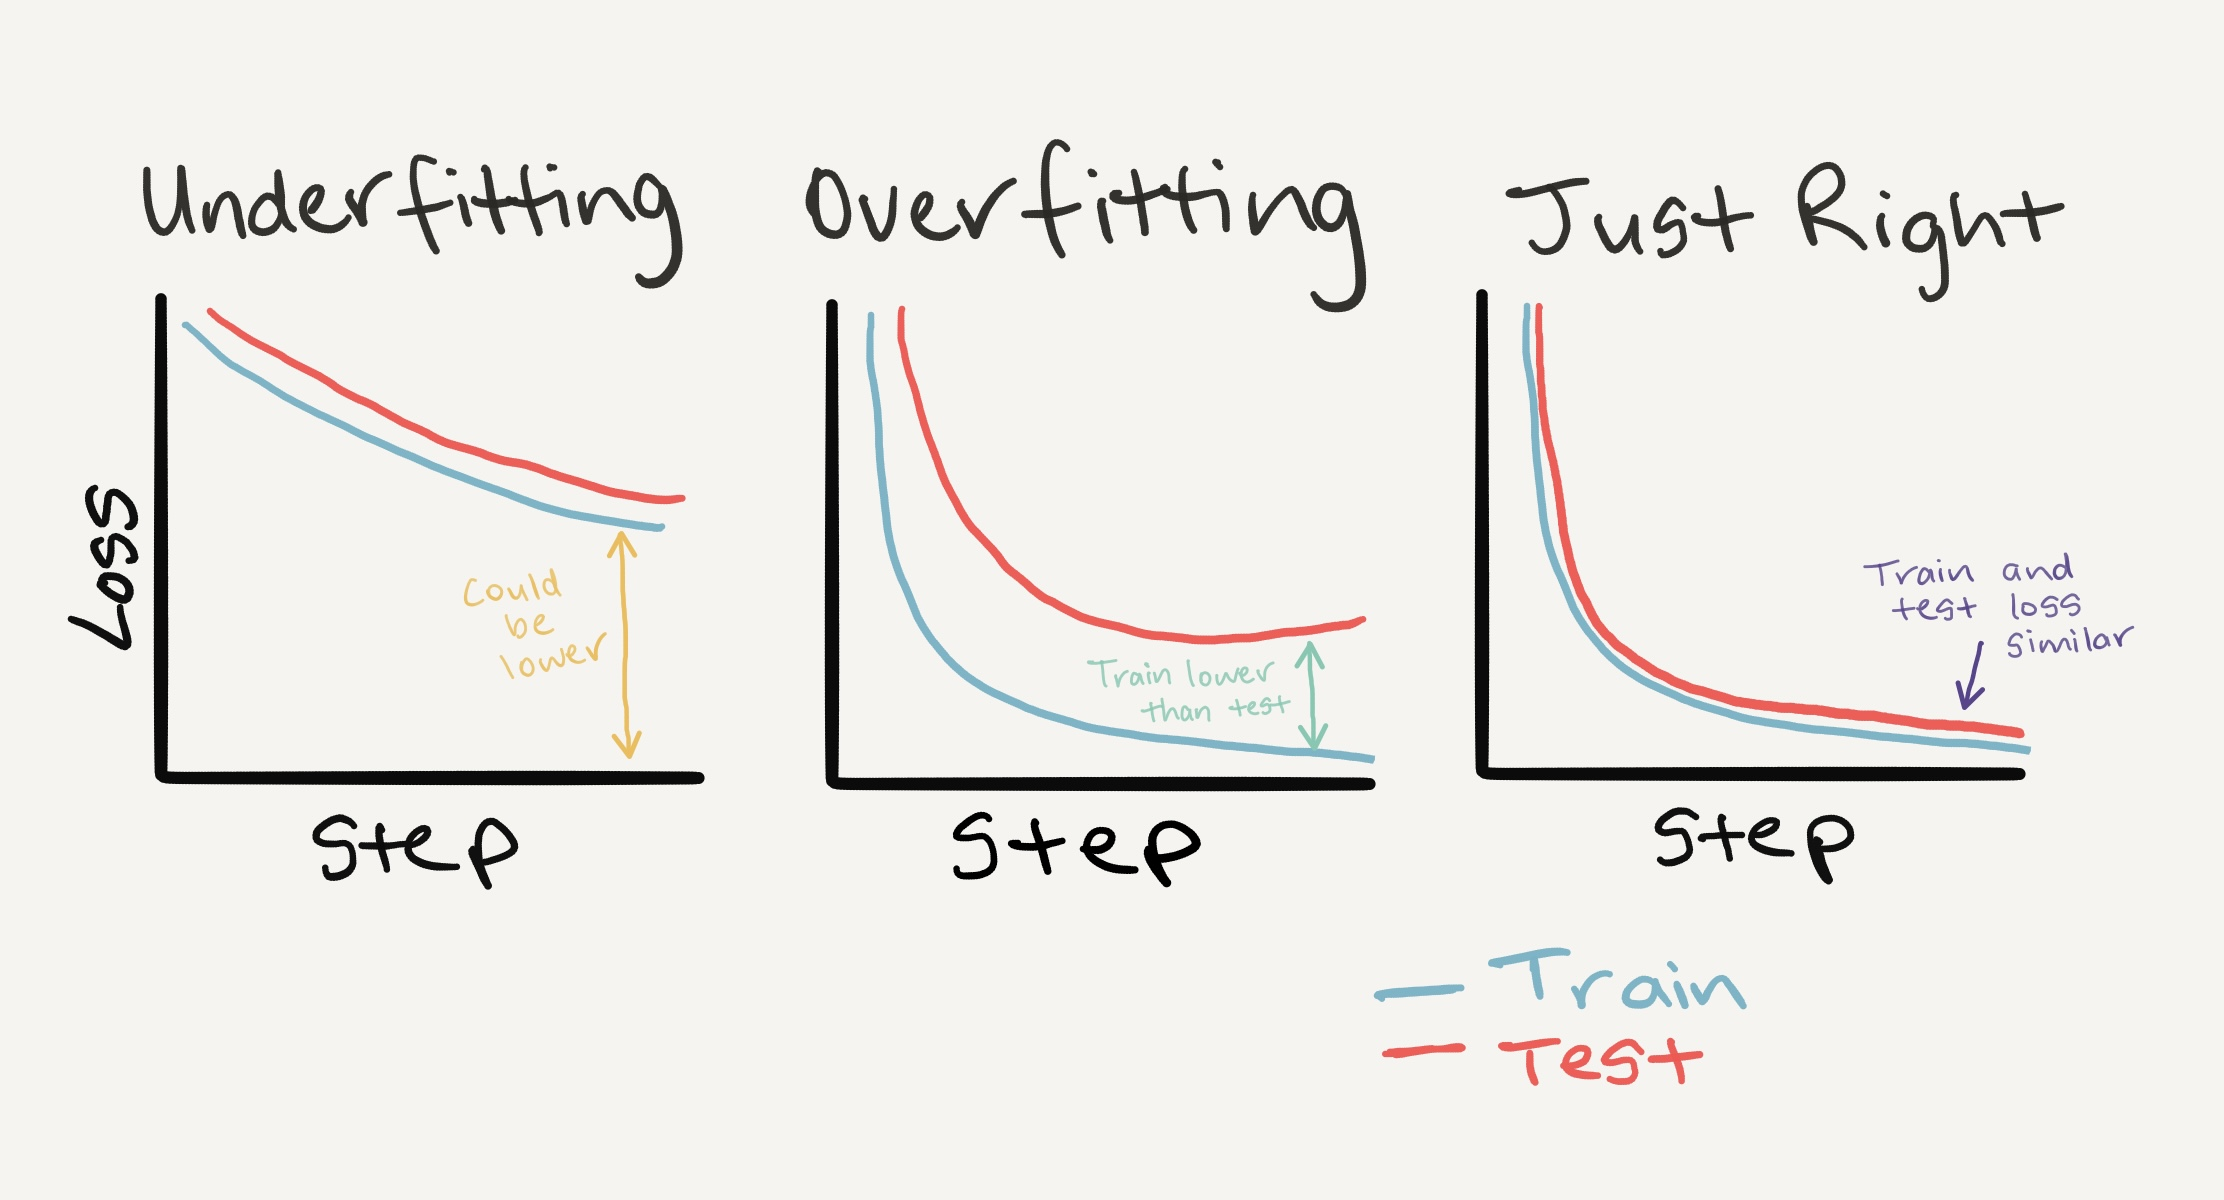

### Model 1: TinyVGG with Data Augmentation

- transforms.TrivialAugmentWide() as well as resize and turn our images into tensors.

In [52]:
# Create training transform with TrivialAugment
train_transform_trivial_augment = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

# Create testing transform (no data augmentation)
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

#### Create train and test datasets and dataloaders

In [53]:
# Turn image folders into Datasets
train_data_aug = datasets.ImageFolder(train_dir, transform=train_transform_trivial_augment)
test_data_simple = datasets.ImageFolder(test_dir, transform=test_transform)

train_data_aug, test_data_simple

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [54]:
#turn our datasets into dataloaders

import os
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)

train_dataloader_aug = DataLoader(train_data_aug,
                                  batch_size = BATCH_SIZE,
                                  shuffle = True,
                                  num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

train_dataloader_aug, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7abf77036540>,
 <torch.utils.data.dataloader.DataLoader at 0x7abf772f3b00>)

#### Train Model 1

- The difference here is that this model 1 will dealing with augmented images compared to the ones in model 0

##### Create model 1 and send it to the target device

In [55]:
torch.manual_seed(42)

model1 = TinyVGG(input_shape=3,
                 hidden_units=10, output_shape=len(train_data_aug.classes)).to(device)

model1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

##### training, loss and optimizer

In [56]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set the number of epochs
NUM_EPOCHS = 5

#setup loss function
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(params = model1.parameters(),
                       lr = 0.001)

#start the timer
from timeit import default_timer as timer
start_time = timer()

#train model1
model1_results = train(model = model1, train_dataloader=train_dataloader_aug,
                       test_dataloader=test_dataloader_simple,
                       optimizer=opt,
                       loss_fn = loss_fn,
                       epochs = NUM_EPOCHS)


# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1076 | train_acc: 0.2500 | test_loss: 1.1062 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0791 | train_acc: 0.4258 | test_loss: 1.1387 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.0810 | train_acc: 0.4258 | test_loss: 1.1695 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1291 | train_acc: 0.3047 | test_loss: 1.1622 | test_acc: 0.2604
Epoch: 5 | train_loss: 1.0901 | train_acc: 0.4258 | test_loss: 1.1476 | test_acc: 0.2604
Total training time: 9.695 seconds


looks like despite using data augmentation - it didnt increase the score at all. \
it has .. infact.. increased the loss.

In [57]:
model1_results

{'train_loss': [1.1075641363859177,
  1.079112447798252,
  1.0809818133711815,
  1.1291434466838837,
  1.0901152417063713],
 'train_acc': [0.25, 0.42578125, 0.42578125, 0.3046875, 0.42578125],
 'test_loss': [1.1062227090199788,
  1.1387030084927876,
  1.1695336898167927,
  1.1621898412704468,
  1.1475936571757],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667]}

##### Plotting model1 results

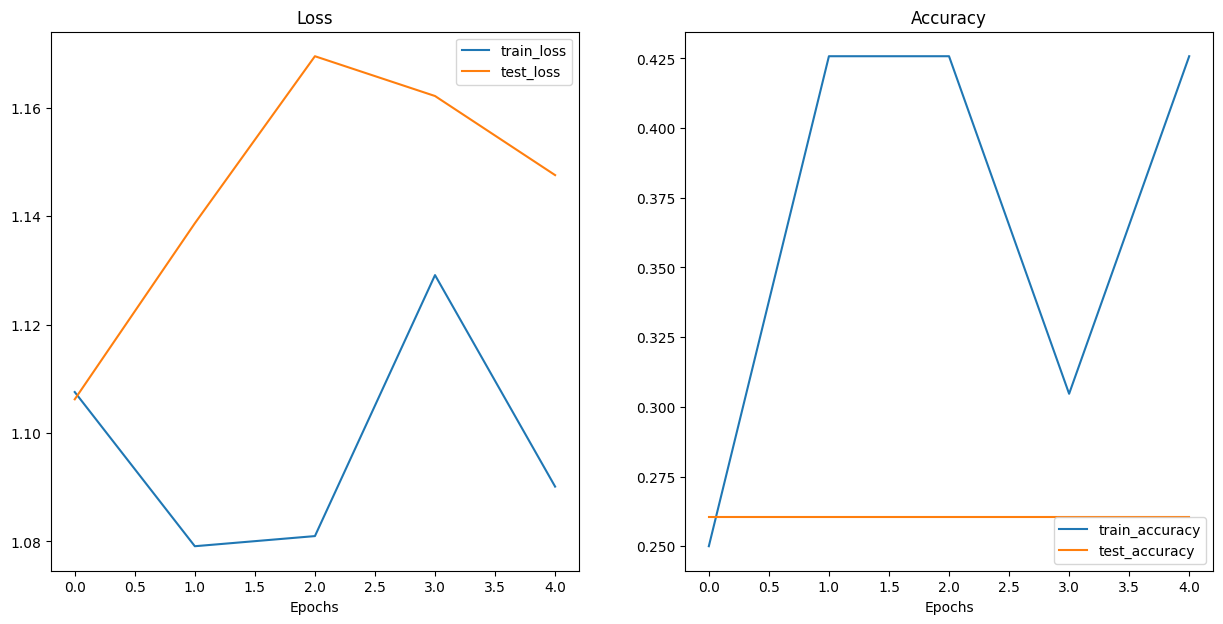

In [58]:
plotloss(model1_results)

#### Compare the model results

In [59]:
import pandas as pd
model_0_df = pd.DataFrame(model0_results)
model_1_df = pd.DataFrame(model1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.107836,0.257812,1.136208,0.260417
1,1.084645,0.425781,1.162169,0.197917
2,1.115265,0.292969,1.169474,0.197917
3,1.099020,0.289062,1.134233,0.197917
4,1.098930,0.292969,1.143426,0.197917


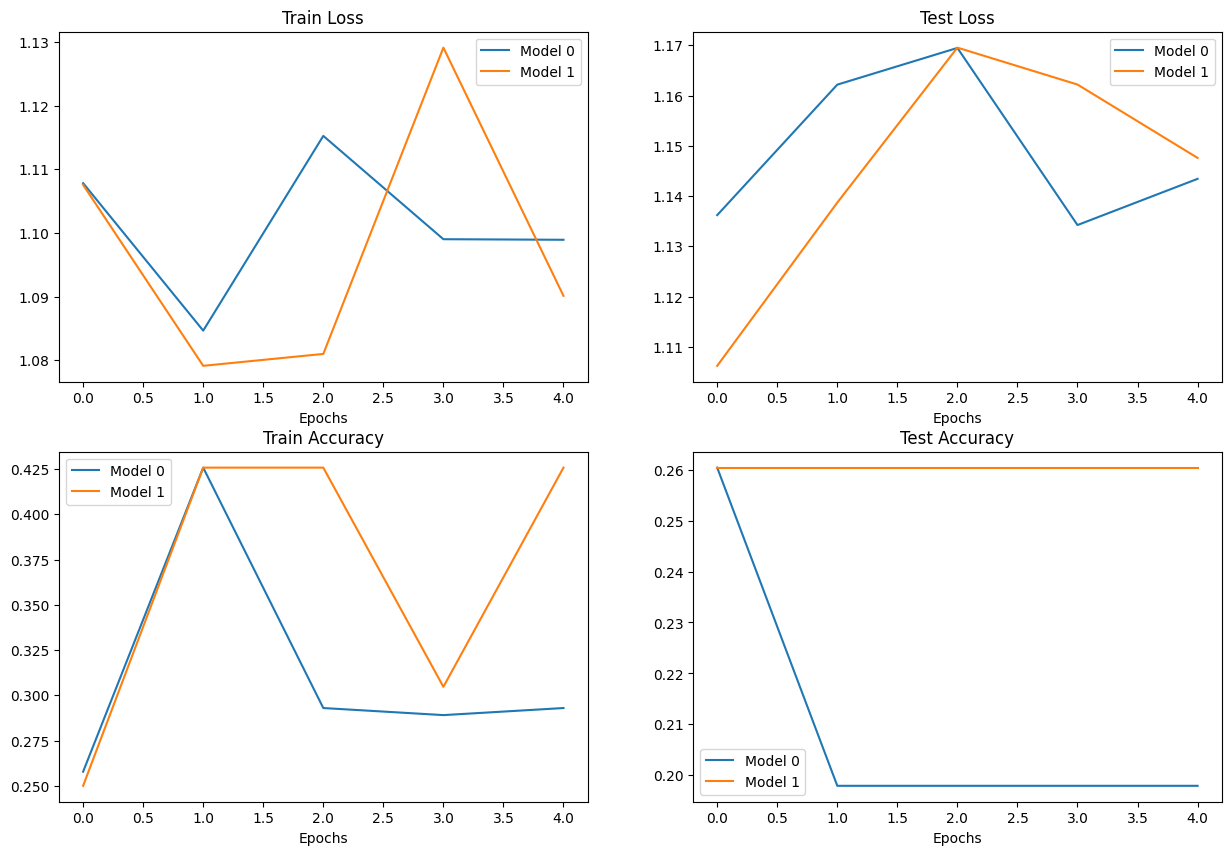

In [60]:
# Setup a plot
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();

### Predict on an image not based in our training or testing data

#### Download the custom image

In [61]:
import requests

#setup custom image path

cuspath = datapath / "04-pizza-dad.jpeg"

if not cuspath.is_file():
  with open(cuspath, "wb") as f:
    #use raw version when downloading from github
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
    print(f"Downloading {cuspath}...")
    f.write(request.content)

else:
  print(f"{cuspath} already exists, skipping download.")

data/04-pizza-dad.jpeg already exists, skipping download.


#### Loading custom image with pytorch

- in tensor form with datatype (torch.float32)

- of shape 64x64x3

- on the correct device

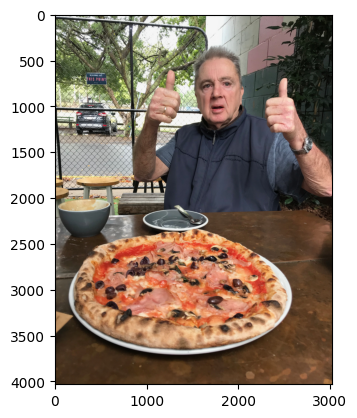

In [62]:
import torchvision

cusimage_uint8 = torchvision.io.read_image(str(cuspath))
plt.imshow(cusimage_uint8.permute(1,2,0))

In [63]:
import torchvision

# Read in custom image
cusimage_uint8 = torchvision.io.read_image(str(cuspath))

# Print out image data
print(f"Custom image tensor:\n{cusimage_uint8}\n")
print(f"Custom image shape: {cusimage_uint8.shape}\n")
print(f"Custom image dtype: {cusimage_uint8.dtype}")

Custom image tensor:
tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

Custom image shape: torch.Size([3, 4032, 3024])

Custom image dty

#### Prediction on a trained Pytorch model

In [74]:
#model1.eval()

#with torch.inference_mode():
  #model1(cusimage_uint8.to(device))

- we have input the custom image as uint8, however we have an error here.

- so we have turn the image into a format where the model can take it / the format where the model is trained to take the input image

#### Load the custom image and convert to float32

In [75]:
cusimage = torchvision.io.read_image(str(cuspath)).type(torch.float32)

cusimage

tensor([[[154., 173., 181.,  ...,  21.,  18.,  14.],
         [146., 165., 181.,  ...,  21.,  18.,  15.],
         [124., 146., 172.,  ...,  18.,  17.,  15.],
         ...,
         [ 72.,  59.,  45.,  ..., 152., 150., 148.],
         [ 64.,  55.,  41.,  ..., 150., 147., 144.],
         [ 64.,  60.,  46.,  ..., 149., 146., 143.]],

        [[171., 190., 193.,  ...,  22.,  19.,  15.],
         [163., 182., 193.,  ...,  22.,  19.,  16.],
         [141., 163., 184.,  ...,  19.,  18.,  16.],
         ...,
         [ 55.,  42.,  28.,  ..., 107., 104., 103.],
         [ 47.,  38.,  24.,  ..., 108., 104., 102.],
         [ 47.,  43.,  29.,  ..., 107., 104., 101.]],

        [[119., 138., 147.,  ...,  17.,  14.,  10.],
         [111., 130., 145.,  ...,  17.,  14.,  11.],
         [ 87., 111., 136.,  ...,  14.,  13.,  11.],
         ...,
         [ 35.,  22.,   8.,  ...,  52.,  52.,  48.],
         [ 27.,  18.,   4.,  ...,  50.,  49.,  44.],
         [ 27.,  23.,   9.,  ...,  49.,  46.,  43.]]]

In [76]:
cusimage.shape

torch.Size([3, 4032, 3024])

⚓ u see these values? its huge.

- the dad pizza image is much larger than we had expected.

- we have to normalize to bring to the range of 0 to 1, which the model can learn

👊 how do we do it?

- we divide it by 255, as images are matrices between 0 to 255.

In [77]:
cusimage = torchvision.io.read_image(str(cuspath)).type(torch.float32)

# Divide the image pixel values by 255 to get them between [0, 1]
cusimage = cusimage / 255.

# Print out image data
print(f"Custom image tensor:\n{cusimage}\n")
print(f"Custom image shape: {cusimage.shape}\n")
print(f"Custom image dtype: {cusimage.dtype}")

Custom image tensor:
tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..

#### Create transform pipeline to resize image and transform image

In [78]:
from torchvision import transforms

cusimagetrans = transforms.Compose([
    transforms.Resize((64,64))
])

cusimagetransformed = cusimagetrans(cusimage)

# Print out original shape and new shape
print(f"Original shape: {cusimage.shape}")
print(f"New shape: {cusimagetransformed.shape}")

Original shape: torch.Size([3, 4032, 3024])
New shape: torch.Size([3, 64, 64])


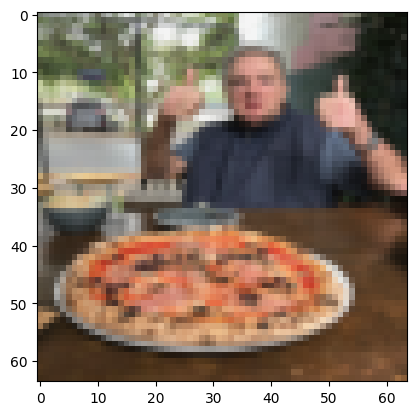

In [79]:
plt.imshow(cusimagetransformed.permute(1,2,0))

errors still happen. lets add a batch size dimensions to this.

In [87]:
model1.eval()

# Add a batch dimension and apply the same transformations as the training data
transformed_image_with_batch = cusimagetransformed.unsqueeze(0).to(device).clone().detach()

with torch.inference_mode():
  # Make prediction
  prediction_logits = model1(transformed_image_with_batch)
  # Clone and detach prediction_logits to ensure it's a 'normal' tensor
  prediction_logits = prediction_logits.clone().detach()
  print(f"Prediction logits: {prediction_logits}")

  # Convert logits to prediction probabilities
  prediction_probs = torch.softmax(prediction_logits, dim=1)
  print(f"Prediction probabilities: {prediction_probs}")

  # Get the predicted label
  prediction_label = torch.argmax(prediction_probs, dim=1)
  print(f"Predicted label: {prediction_label}")
  print(f"Predicted class: {train_data_aug.classes[prediction_label.item()]}")

Prediction logits: tensor([[ 0.1181,  0.0340, -0.1461]], device='cuda:0')
Prediction probabilities: tensor([[0.3721, 0.3421, 0.2857]], device='cuda:0')
Predicted label: tensor([0], device='cuda:0')
Predicted class: pizza


In [86]:
model1.eval()

with torch.inference_mode():
  # Make prediction
  prediction_logits = model1(transformed_image_with_batch)
  # Clone and detach prediction_logits to ensure it's a 'normal' tensor
  prediction_logits = prediction_logits.clone().detach()
  print(f"Prediction logits: {prediction_logits}")

  # Convert logits to prediction probabilities
  prediction_probs = torch.softmax(prediction_logits, dim=1)
  print(f"Prediction probabilities: {prediction_probs}")

  # Get the predicted label
  prediction_label = torch.argmax(prediction_probs, dim=1)
  print(f"Predicted label: {prediction_label}")
  print(f"Predicted class: {train_data_aug.classes[prediction_label.item()]}")

Prediction logits: tensor([[ 0.1181,  0.0340, -0.1461]], device='cuda:0')
Prediction probabilities: tensor([[0.3721, 0.3421, 0.2857]], device='cuda:0')
Predicted label: tensor([0], device='cuda:0')
Predicted class: pizza


In [82]:
# Convert logits to prediction probabilities
prediction_probs = torch.softmax(prediction_logits, dim=1)
print(f"Prediction probabilities: {prediction_probs}")

Prediction probabilities: tensor([[0.3721, 0.3421, 0.2857]], device='cuda:0')


In [83]:
# Get the predicted label
prediction_label = torch.argmax(prediction_probs, dim=1)
print(f"Predicted label: {prediction_label}")
print(f"Predicted class: {train_data_aug.classes[prediction_label.item()]}")

Predicted label: tensor([0], device='cuda:0')
Predicted class: pizza


### Common Pytorch Issues

- **Wrong datatypes** - our model expects torch.float32 where our original custom image was uint8.

- **Wrong device** - our model was on the target device (in our case, the GPU) whereas our target data hadn't been moved to the target device yet.

- **Wrong shapes** - our model expected an input image of shape [N, C, H, W] or [batch_size, color_channels, height, width] whereas our custom image tensor was of shape [color_channels, height, width].

#### Putting custom image prediction together: building a function

an all encompassing function to perform the following:

- pass an image path
- have the model predict on that image
- plot the image + prediction

In [84]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform=None,
                        device: torch.device = device):
    """Makes a prediction on a target image and plots the image with its prediction."""

    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image = target_image / 255.

    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image)

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))

    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);

#### Test the function out

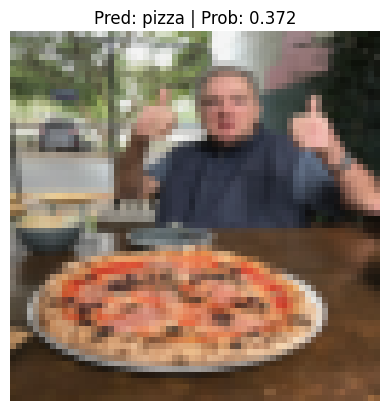

In [88]:
# Pred on our custom image
pred_and_plot_image(model=model1,
                    image_path=cuspath,
                    class_names=classnames,
                    transform=cusimagetrans,
                    device=device)

the model has predicted the image correctly

this is the end of this notebook.